# Zero-temperature amplitude damping channel — noiseless

This notebook adds no noise on top of the same analytic-SVD amplitude-damping workflow.

Main things to tweak:
- `gamma`
- the time grid
- `shots`


In [18]:
import sys
import os
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

project_root = os.path.abspath('../..')
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from timeevo.ampdamp.ampdamp_channel import (
    analytic_svd_for_amplitude_damping,
    amplitude_damping_kraus_operators,
    exact_amplitude_damping_density_matrix,
    exact_coherence_formula,
    exact_population_formula,
    paper_initial_density_matrix,
    paper_initial_state_decomposition,
    paper_time_grid,
    simulate_amplitude_damping_trajectory,
)

from plot.coherence_plot import (plot_coherence_comparison, plot_populations_and_coherence_comparison, )
from noise.noise_simulation import SimpleNISQNoiseParameters

In [19]:
# Tweakable parameters
gamma = 0.015
times = paper_time_grid(t_max=50.0, num_points=26)
shots = 32000      # use an integer like 2048 to include finite-shot tomography
seed = 7


## Inspect the analytic SVD and Kraus operators at one time

In [20]:
t_inspect = 8.0

K0, K1 = amplitude_damping_kraus_operators(t_inspect, gamma=gamma)
svd0 = analytic_svd_for_amplitude_damping(t_inspect, branch=0, gamma=gamma)
svd1 = analytic_svd_for_amplitude_damping(t_inspect, branch=1, gamma=gamma)

print("K0 =\n", K0)
print("K1 =\n", K1)
print()

print("SVD for K0")
print("U =\n", svd0.U)
print("Sigma =\n", svd0.Sigma)
print("Vh =\n", svd0.Vh)
print("Reconstructed K0 =\n", svd0.reconstruct())
print("max |reconstruct - K0| =", np.max(np.abs(svd0.reconstruct() - K0)))
print()

print("SVD for K1")
print("U =\n", svd1.U)
print("Sigma =\n", svd1.Sigma)
print("Vh =\n", svd1.Vh)
print("Reconstructed K1 =\n", svd1.reconstruct())
print("max |reconstruct - K1| =", np.max(np.abs(svd1.reconstruct() - K1)))


K0 =
 [[1.        +0.j 0.        +0.j]
 [0.        +0.j 0.94176453+0.j]]
K1 =
 [[0.        +0.j 0.33627305+0.j]
 [0.        +0.j 0.        +0.j]]

SVD for K0
U =
 [[1.+0.j 0.+0.j]
 [0.+0.j 1.+0.j]]
Sigma =
 [[1.         0.        ]
 [0.         0.94176453]]
Vh =
 [[1.+0.j 0.+0.j]
 [0.+0.j 1.+0.j]]
Reconstructed K0 =
 [[1.        +0.j 0.        +0.j]
 [0.        +0.j 0.94176453+0.j]]
max |reconstruct - K0| = 0.0

SVD for K1
U =
 [[1.+0.j 0.+0.j]
 [0.+0.j 1.+0.j]]
Sigma =
 [[0.33627305 0.        ]
 [0.         0.        ]]
Vh =
 [[0.+0.j 1.+0.j]
 [1.+0.j 0.+0.j]]
Reconstructed K1 =
 [[0.        +0.j 0.33627305+0.j]
 [0.        +0.j 0.        +0.j]]
max |reconstruct - K1| = 0.0


## The paper's initial mixed state and its pure-state decomposition

In [21]:
rho0 = paper_initial_density_matrix()
decomp = paper_initial_state_decomposition()

print("rho(0) =\n", rho0)
for weight, ket, label in decomp:
    print(label, "weight =", weight, "ket =", ket)


rho(0) =
 [[0.25+0.j 0.25+0.j]
 [0.25+0.j 0.75+0.j]]
|1> weight = 0.5 ket = [0.+0.j 1.+0.j]
|+> weight = 0.5 ket = [0.70710678+0.j 0.70710678+0.j]


## Simulate the trajectory

In [22]:
result = simulate_amplitude_damping_trajectory(
    times,
    gamma=gamma,
    shots=shots,
    seed=seed,
    noise_params=None,
)

print("Exact rho(t=0) =\n", result.exact_density_matrices[0])
print()
print("Obtained rho(t=0) =\n", result.obtained_density_matrices[0])
print()
print("Max abs difference over trajectory =",
      np.max(np.abs(result.exact_density_matrices - result.obtained_density_matrices)))


Exact rho(t=0) =
 [[0.25+0.j 0.25+0.j]
 [0.25+0.j 0.75+0.j]]

Obtained rho(t=0) =
 [[0.25147294+0.j         0.24979223+0.00103123j]
 [0.24979223-0.00103123j 0.74852706+0.j        ]]

Max abs difference over trajectory = 0.0038325451563218206


## Population & Coherence plot: exact curve and obtained data

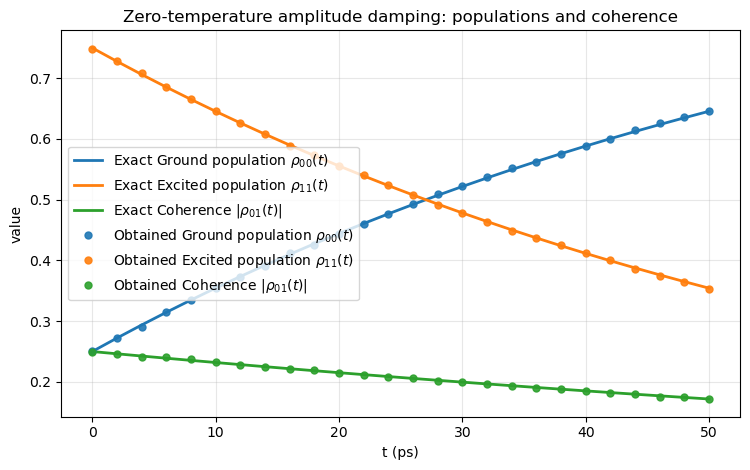

In [23]:
fig, ax = plot_populations_and_coherence_comparison(
    times,
    result.exact_density_matrices,
    result.obtained_density_matrices,
    coherence_component="abs",   # change to "imag", "abs", or "phase" if desired
    colors=["tab:blue", "tab:orange", "tab:green"],
    title="Zero-temperature amplitude damping: populations and coherence",
    xlabel="t (ps)",
)
plt.show()



## Saves the figure

In [24]:
out_dir = Path.cwd()
fig.savefig(out_dir / 'ampdamp_noiseless_population_coherence.png', dpi=200, bbox_inches='tight')
plt.close(fig)


## Optional: separate coherence-only plot

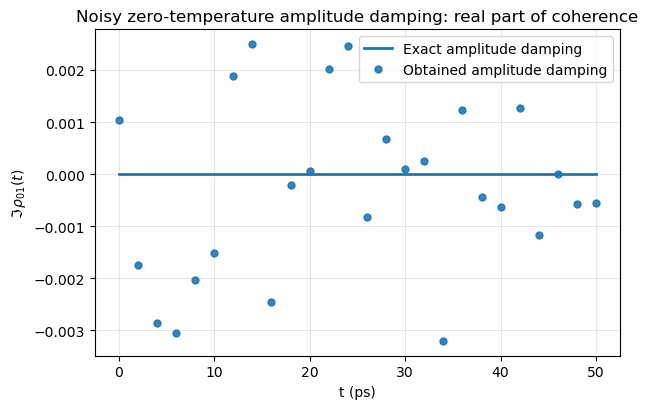

In [25]:
fig, ax = plot_coherence_comparison(
    result.coherence_exact,
    result.coherence_obtained,
    component="imag",   # change to "imag", "abs", "phase", or "complex"
    title="Noisy zero-temperature amplitude damping: real part of coherence",
    xlabel="t (ps)",
)
plt.show()